# Setup

In [1]:
import numpy as np
import pandas as pd
import random

import torch
import torch.nn as nn
import torch.nn.functional as F

import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import OrderedDict
from tqdm import tqdm

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Check for CUDA support
if torch.cuda.is_available():
    device = torch.device('cuda:4')  # Use GPU X if available
else:
    device = torch.device('cpu')     # Fallback to CPU if no GPU is available
    
print(device)


cuda:4


# Read data

In [3]:
folder_path = '/raid/sepideh/Project_MCL/1D-AEMpy-UW-metabolism-BM'
file_path = os.path.join(folder_path, "all_data_lake_modeling_process_based.csv")

df = pd.read_csv(file_path)

In [4]:
df.columns

Index(['datetime', 'depth', 'do_ax01', 'do_bc02', 'do_conv05', 'do_diff04',
       'do_final06', 'do_initial00', 'do_pd03', 'doc_final06', 'docl_bc02',
       'docl_conv05', 'docl_diff04', 'docl_initial00', 'docl_pd03',
       'docl_resp_pd03', 'docr_bc02', 'docr_conv05', 'docr_diff04',
       'docr_initial00', 'docr_pd03', 'docr_resp_pd03', 'kz_initial00',
       'npp_bc02', 'poc_final06', 'poc_resp_pd03', 'pocl_bc02', 'pocl_conv05',
       'pocl_diff04', 'pocl_initial00', 'pocl_pd03', 'pocr_bc02',
       'pocr_conv05', 'pocr_diff04', 'pocr_initial00', 'pocr_pd03',
       'temp_conv05', 'temp_diff04', 'temp_final06', 'temp_initial00',
       'scaled_chla_final06', 'Air_Temperature_celsius',
       'Shortwave_Radiation_Downwelling_wattPerMeterSquared',
       'Longwave_Radiation_Downwelling_wattPerMeterSquared',
       'Relative_Humidity_percent',
       'Ten_Meter_Elevation_Wind_Speed_meterPerSecond',
       'Precipitation_millimeterPerDay',
       'Surface_Level_Barometric_Pressure_p

In [5]:
# create new variables
df['doc_diff04'] = df['docr_diff04'] + df['docl_diff04']
df['poc_diff04'] = df['pocr_diff04'] + df['pocl_diff04']

In [6]:
all_columns= ['depth', 
            'datetime', 'day_of_year_list', 'time_of_day_list', # time features
            
            # inputs
            'temp_initial00', 'do_pd03', 'docl_pd03', 'docr_pd03', 'pocl_pd03', 'pocr_pd03', 'kz_initial00', 
            'Ten_Meter_Elevation_Wind_Speed_meterPerSecond', 
            'area_input', 'volume_input',

            # output
            'do_diff04','scaled_chla_final06','doc_diff04'
            #'doc_diff04'
            ]
df_m = df[all_columns]
df_m

,depth,datetime,day_of_year_list,time_of_day_list,temp_initial00,do_pd03,docl_pd03,docr_pd03,pocl_pd03,pocr_pd03,kz_initial00,Ten_Meter_Elevation_Wind_Speed_meterPerSecond,area_input,volume_input,do_diff04,scaled_chla_final06,doc_diff04
0,0.0,2016-05-17 18:00:00,138,18,15.800000,2.227493e+08,1.995459e+07,1.000826e+08,1.014997e+07,9.921259e+06,2.017408e-03,3.327762,38887500.0,19925000.0,2.227493e+08,-0.101339,1.200372e+08
1,1.0,2016-05-17 18:00:00,138,18,15.600000,2.201040e+08,1.896995e+07,9.444764e+07,9.575018e+06,9.443247e+06,2.017408e-03,3.327762,36962500.0,18962500.0,2.106391e+08,-0.101339,1.134381e+08
2,2.0,2016-05-17 18:00:00,138,18,15.400000,2.096759e+08,1.799542e+07,8.889388e+07,9.041366e+06,8.964666e+06,1.007739e-03,3.327762,35500000.0,18000000.0,2.049932e+08,-0.101339,1.069136e+08
3,3.0,2016-05-17 18:00:00,138,18,15.200000,2.055109e+08,1.748882e+07,8.568574e+07,8.761996e+06,8.716487e+06,4.097332e-04,3.327762,34500000.0,17500000.0,2.025911e+08,-0.101339,1.031977e+08
4,4.0,2016-05-17 18:00:00,138,18,14.800000,2.012874e+08,1.698532e+07,8.251981e+07,8.495214e+06,8.468185e+06,2.030611e-04,3.327762,33525000.0,17000000.0,1.990979e+08,-0.101220,9.952847e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2189995,45.0,2021-05-16 17:00:00,136,17,7.536653,1.365336e+07,7.245855e+05,5.788974e+06,2.181818e+06,4.557371e+04,3.759233e-07,4.378333,2075000.0,1275000.0,1.365258e+07,-0.095987,6.513562e+06
2189996,46.0,2021-05-16 17:00:00,136,17,7.532475,8.398730e+06,4.547444e+05,3.632589e+06,1.845341e+06,3.855036e+04,3.294472e-07,4.378333,1225000.0,800000.0,8.397004e+06,-0.090439,4.087344e+06
2189997,47.0,2021-05-16 17:00:00,136,17,7.486889,4.154155e+06,2.419809e+05,1.930929e+06,1.519268e+06,3.174008e+04,1.781493e-07,4.378333,475000.0,425000.0,4.149462e+06,-0.078666,2.172939e+06
2189998,48.0,2021-05-16 17:00:00,136,17,7.060261,2.183402e+05,2.891345e+04,2.283447e+05,1.213022e+06,2.534255e+04,1.350280e-07,4.378333,75000.0,50000.0,2.184360e+05,0.112488,2.572772e+05


# Preprocessing

In [7]:
df_m.columns

Index(['depth', 'datetime', 'day_of_year_list', 'time_of_day_list',
       'temp_initial00', 'do_pd03', 'docl_pd03', 'docr_pd03', 'pocl_pd03',
       'pocr_pd03', 'kz_initial00',
       'Ten_Meter_Elevation_Wind_Speed_meterPerSecond', 'area_input',
       'volume_input', 'do_diff04', 'scaled_chla_final06', 'doc_diff04'],
      dtype='object')

In [8]:
# Specify input and output columns

input_binary = ['ice_final06'] # remain unchanged
input_time = ['day_of_year_list', 'time_of_day_list', 'datetime'] # sin and cos

output_columns = ['do_diff04','scaled_chla_final06','doc_diff04']

features_to_normalize = list(set(all_columns) - set(input_binary + input_time))
features_to_normalize



['do_diff04',
 'area_input',
 'Ten_Meter_Elevation_Wind_Speed_meterPerSecond',
 'temp_initial00',
 'docl_pd03',
 'do_pd03',
 'doc_diff04',
 'depth',
 'scaled_chla_final06',
 'docr_pd03',
 'pocr_pd03',
 'volume_input',
 'pocl_pd03',
 'kz_initial00']

### Split data train-val-test

In [9]:

training_frac = 0.60
val_frac = 0.2

depth_steps = 50
number_days = len(df_m)//depth_steps

# Calculate number of observations for each set
n_obs_train = int(number_days * training_frac) * depth_steps
n_obs_val = int(number_days * val_frac) * depth_steps

print(f"Number of days total: {number_days}")


Number of days total: 43800


In [10]:
train_df_unnormalized = df_m.iloc[:n_obs_train]
val_df_unnormalized = df_m.iloc[n_obs_train:n_obs_train + n_obs_val]
test_df_unnormalized = df_m.iloc[n_obs_train + n_obs_val:]

print(f"Number of training points: {train_df_unnormalized.shape}")
print(f"Number of validation points: {val_df_unnormalized.shape}")
print(f"Number of test points: {test_df_unnormalized.shape}")

Number of training points: (1314000, 17)
Number of validation points: (438000, 17)
Number of test points: (438000, 17)


In [11]:
print(f"train time: from {train_df_unnormalized.iloc[0]['datetime']} to {train_df_unnormalized.iloc[-1]['datetime']}")
print(f"val time: from {val_df_unnormalized.iloc[0]['datetime']} to {val_df_unnormalized.iloc[-1]['datetime']}")
print(f"test time: from {test_df_unnormalized.iloc[0]['datetime']} to {test_df_unnormalized.iloc[-1]['datetime']}")


train time: from 2016-05-17 18:00:00 to 2019-05-17 17:00:00
val time: from 2019-05-17 18:00:00 to 2020-05-16 17:00:00
test time: from 2020-05-16 18:00:00 to 2021-05-16 17:00:00


### Preprocess time feature

In [12]:
def add_cyclical_features(df, feature, cycle_length):
    sin_col = f"{feature}_sin"
    cos_col = f"{feature}_cos"
    df[sin_col] = np.sin(2 * np.pi * df[feature].values / cycle_length)
    df[cos_col] = np.cos(2 * np.pi * df[feature].values / cycle_length)
    return df


In [13]:
train_df = add_cyclical_features(train_df_unnormalized, 'day_of_year_list', 365)
train_df = add_cyclical_features(train_df_unnormalized, 'time_of_day_list', 24)

test_df = add_cyclical_features(test_df_unnormalized, 'day_of_year_list', 365)
test_df = add_cyclical_features(test_df_unnormalized, 'time_of_day_list', 24)

val_df = add_cyclical_features(val_df_unnormalized, 'day_of_year_list', 365)
val_df = add_cyclical_features(val_df_unnormalized, 'time_of_day_list', 24)

# Drop the original day_of_year_list and time_of_day_list as they are now represented in sin and cos
train_df = train_df_unnormalized.drop(columns=['day_of_year_list', 'time_of_day_list', 'datetime'])
test_df = test_df_unnormalized.drop(columns=['day_of_year_list', 'time_of_day_list', 'datetime'])
val_df = val_df_unnormalized.drop(columns=['day_of_year_list', 'time_of_day_list', 'datetime'])

In [14]:
train_df

,depth,temp_initial00,do_pd03,docl_pd03,docr_pd03,pocl_pd03,pocr_pd03,kz_initial00,Ten_Meter_Elevation_Wind_Speed_meterPerSecond,area_input,volume_input,do_diff04,scaled_chla_final06,doc_diff04,day_of_year_list_sin,day_of_year_list_cos,time_of_day_list_sin,time_of_day_list_cos
0,0.0,15.800000,2.227493e+08,1.995459e+07,1.000826e+08,1.014997e+07,9.921259e+06,2.017408e-03,3.327762,38887500.0,19925000.0,2.227493e+08,-0.101339,1.200372e+08,0.693281,-0.720667,-1.000000,-1.836970e-16
1,1.0,15.600000,2.201040e+08,1.896995e+07,9.444764e+07,9.575018e+06,9.443247e+06,2.017408e-03,3.327762,36962500.0,18962500.0,2.106391e+08,-0.101339,1.134381e+08,0.693281,-0.720667,-1.000000,-1.836970e-16
2,2.0,15.400000,2.096759e+08,1.799542e+07,8.889388e+07,9.041366e+06,8.964666e+06,1.007739e-03,3.327762,35500000.0,18000000.0,2.049932e+08,-0.101339,1.069136e+08,0.693281,-0.720667,-1.000000,-1.836970e-16
3,3.0,15.200000,2.055109e+08,1.748882e+07,8.568574e+07,8.761996e+06,8.716487e+06,4.097332e-04,3.327762,34500000.0,17500000.0,2.025911e+08,-0.101339,1.031977e+08,0.693281,-0.720667,-1.000000,-1.836970e-16
4,4.0,14.800000,2.012874e+08,1.698532e+07,8.251981e+07,8.495214e+06,8.468185e+06,2.030611e-04,3.327762,33525000.0,17000000.0,1.990979e+08,-0.101220,9.952847e+07,0.693281,-0.720667,-1.000000,-1.836970e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313995,45.0,7.341026,1.277035e+07,6.301570e+05,5.891679e+06,2.091764e+06,5.622107e+04,1.836624e-06,5.310009,2075000.0,1275000.0,1.275729e+07,-0.094509,6.521983e+06,0.705584,-0.708627,-0.965926,-2.588190e-01
1313996,46.0,7.241680,7.391995e+06,3.987005e+05,3.699272e+06,1.828848e+06,4.915469e+04,1.022466e-06,5.310009,1225000.0,800000.0,7.379375e+06,-0.087773,4.098141e+06,0.705584,-0.708627,-0.965926,-2.588190e-01
1313997,47.0,6.963334,3.168639e+06,2.168236e+05,1.969046e+06,1.565326e+06,4.207196e+04,5.835225e-07,5.310009,475000.0,425000.0,3.155743e+06,-0.073195,2.186059e+06,0.705584,-0.708627,-0.965926,-2.588190e-01
1313998,48.0,6.032399,1.108733e+05,2.753391e+04,2.331673e+05,1.311515e+06,3.525021e+04,5.376821e-07,5.310009,75000.0,50000.0,1.120954e+05,0.161427,2.607410e+05,0.705584,-0.708627,-0.965926,-2.588190e-01


### Normalize other features

In [15]:
features_to_normalize

['do_diff04',
 'area_input',
 'Ten_Meter_Elevation_Wind_Speed_meterPerSecond',
 'temp_initial00',
 'docl_pd03',
 'do_pd03',
 'doc_diff04',
 'depth',
 'scaled_chla_final06',
 'docr_pd03',
 'pocr_pd03',
 'volume_input',
 'pocl_pd03',
 'kz_initial00']

In [16]:
train_features_to_normalize = train_df[features_to_normalize].values
val_data_features_to_normalize = val_df[features_to_normalize].values
test_features_to_normalize = test_df[features_to_normalize].values

In [17]:
# Initialize StandardScaler and fit on training features
scaler = StandardScaler()
scaler.fit(train_features_to_normalize)

# Transform training, test, and validation features using the fitted scaler
train_df[features_to_normalize] = scaler.transform(train_features_to_normalize)
val_df[features_to_normalize] = scaler.transform(val_data_features_to_normalize)
test_df[features_to_normalize] = scaler.transform(test_features_to_normalize)

In [18]:
train_df

,depth,temp_initial00,do_pd03,docl_pd03,docr_pd03,pocl_pd03,pocr_pd03,kz_initial00,Ten_Meter_Elevation_Wind_Speed_meterPerSecond,area_input,volume_input,do_diff04,scaled_chla_final06,doc_diff04,day_of_year_list_sin,day_of_year_list_cos,time_of_day_list_sin,time_of_day_list_cos
0,-1.697749,1.392066,1.840076,4.389380,2.424040,0.922646,20.552955,1.278636,-0.444468,1.819655,1.869146,1.839582,-0.103029,2.735999,0.693281,-0.720667,-1.000000,-1.836970e-16
1,-1.628453,1.359058,1.802780,4.099583,2.182619,0.820897,19.544289,1.278636,-0.444468,1.639226,1.689047,1.668885,-0.103029,2.483453,0.693281,-0.720667,-1.000000,-1.836970e-16
2,-1.559158,1.326050,1.655755,3.812763,1.944678,0.726456,18.534424,0.448371,-0.444468,1.502148,1.508948,1.589305,-0.103029,2.233765,0.693281,-0.720667,-1.000000,-1.836970e-16
3,-1.489862,1.293042,1.597034,3.663661,1.807231,0.677016,18.010734,-0.043378,-0.444468,1.408419,1.415390,1.555447,-0.103029,2.091556,0.693281,-0.720667,-1.000000,-1.836970e-16
4,-1.420566,1.227026,1.537487,3.515473,1.671592,0.629804,17.486786,-0.213328,-0.444468,1.317033,1.321832,1.506209,-0.102904,1.951137,0.693281,-0.720667,-1.000000,-1.836970e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313995,1.420566,-0.004001,-1.120394,-1.298132,-1.611409,-0.503414,-0.263513,-0.378798,0.546361,-1.630744,-1.620563,-1.120305,-0.095914,-1.608191,0.705584,-0.708627,-0.965926,-2.588190e-01
1313996,1.489862,-0.020397,-1.196223,-1.366254,-1.705339,-0.549942,-0.278424,-0.379467,0.546361,-1.710414,-1.709443,-1.196108,-0.088897,-1.700951,0.705584,-0.708627,-0.965926,-2.588190e-01
1313997,1.559158,-0.066335,-1.255768,-1.419783,-1.779468,-0.596578,-0.293369,-0.379828,0.546361,-1.780710,-1.779611,-1.255641,-0.073712,-1.774125,0.705584,-0.708627,-0.965926,-2.588190e-01
1313998,1.628453,-0.219977,-1.298879,-1.475494,-1.853839,-0.641494,-0.307764,-0.379866,0.546361,-1.818202,-1.849780,-1.298542,0.170687,-1.847807,0.705584,-0.708627,-0.965926,-2.588190e-01


# Training 

In [19]:
# the deep neural network
class MLP(torch.nn.Module):
    def __init__(self, layers, activation="relu", init="xavier"):
        super(MLP, self).__init__()
        
        # parameters
        self.depth = len(layers) - 1
        
        if activation == "relu":
            self.activation = torch.nn.ReLU()
        elif activation == "tanh":
            self.activation = torch.nn.Tanh()
        elif activation == "gelu":
            self.activation = torch.nn.GELU()
        else:
            raise ValueError("Unspecified activation type")
        
        
        layer_list = list()
        for i in range(self.depth - 1): 
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i+1]))
            )
            layer_list.append(('activation_%d' % i, self.activation))
            
        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)
        
        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

        if init=="xavier":
            self.xavier_init_weights()
        elif init=="kaiming":
            self.kaiming_init_weights()
    
    def xavier_init_weights(self):
        with torch.no_grad():
            print("Initializing Network with Xavier Initialization..")
            for m in self.layers.modules():
                if hasattr(m, 'weight'):
                    nn.init.xavier_uniform_(m.weight)
                    m.bias.data.fill_(0.0)

    def kaiming_init_weights(self):
        with torch.no_grad():
            print("Initializing Network with Kaiming Initialization..")
            for m in self.layers.modules():
                if hasattr(m, 'weight'):
                    nn.init.kaiming_uniform_(m.weight)
                    m.bias.data.fill_(0.0)
                        
    def forward(self, x):
        out = self.layers(x)
        return out
    
class DataGenerator(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
        
    def __getitem__(self, index):
        return self.X[index], self.Y[index]
    
    def __len__(self):
        return len(self.X)

In [20]:
input_columns = [column for column in train_df.columns if column not in output_columns]

input_column_ix = [train_df.columns.get_loc(column) for column in input_columns]
output_column_ix = [train_df.columns.get_loc(column) for column in output_columns]

train_array = train_df.values
test_array = test_df.values
val_array = val_df.values

# Use the column indices to select the input and output data
X_train, X_test, X_val = train_array[:,input_column_ix], test_array[:,input_column_ix], val_array[:, input_column_ix]
y_train, y_test, y_val = train_array[:,output_column_ix], test_array[:,output_column_ix], val_array[:, output_column_ix]


In [21]:
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_val: {y_val.shape}, y_test: {y_test.shape}")


X_train: (1314000, 15), X_val: (438000, 15), X_test: (438000, 15)
y_train: (1314000, 3), y_val: (438000, 3), y_test: (438000, 3)


In [22]:
# Create data set
batch_size = 1024
train_dataset = DataGenerator(X_train, y_train)
val_dataset = DataGenerator(X_val, y_val)
test_dataset = DataGenerator(X_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, 
                                           shuffle=True)

val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                          shuffle=False)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=False)

In [23]:
layers = [X_train.shape[-1], 32, 32, y_train.shape[-1]]

model = MLP(layers, activation="gelu").to(device)

Initializing Network with Xavier Initialization..


In [39]:
lr = 1e-2
decay_rate = 0.01
decay_steps = 500
    
optimizer = torch.optim.Adam(model.parameters(), lr=lr, 
                         betas=(0.9, 0.999), eps=1e-08, weight_decay=0, amsgrad=False)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=decay_steps, gamma=decay_rate)

criterion = torch.nn.MSELoss()

In [40]:
print(model)


MLP(
  (activation): GELU(approximate='none')
  (layers): Sequential(
    (layer_0): Linear(in_features=15, out_features=32, bias=True)
    (activation_0): GELU(approximate='none')
    (layer_1): Linear(in_features=32, out_features=32, bias=True)
    (activation_1): GELU(approximate='none')
    (layer_2): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [41]:
n_epochs = 50

train_loss = []
val_loss = []
for it in tqdm(range(n_epochs)):
    loss_epoch = 0
    model.train()
    for x, y in iter(train_loader):
        x, y = x.to(device).float(), y.to(device).float()
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        loss_epoch += loss.detach().item()
    lr_scheduler.step()
    
    if it % 1 == 0:
        train_loss.append(loss_epoch/len(train_loader))
        model.eval()
        val_loss_epoch = 0
        for x, y in iter(val_loader):
            x, y = x.to(device).float(), y.to(device).float()
            pred = model(x)
            loss = criterion(pred, y)
            val_loss_epoch += loss.detach().item()
        val_loss.append(val_loss_epoch/len(val_loader))
        print(f"Epoch : {it}, Train_loss: {train_loss[-1]}, Val_loss: {val_loss[-1]}")
    

  2%|▏         | 1/50 [00:17<14:31, 17.79s/it]

Epoch : 0, Train_loss: 0.005519761691396516, Val_loss: 0.06399433204538905


  4%|▍         | 2/50 [00:34<13:30, 16.89s/it]

Epoch : 1, Train_loss: 0.003979167077912313, Val_loss: 0.0840367672697148


  6%|▌         | 3/50 [00:50<13:02, 16.64s/it]

...

Epoch : 47, Train_loss: 0.0008952907188710281, Val_loss: 0.052703830663112884


 98%|█████████▊| 49/50 [13:06<00:15, 15.68s/it]

Epoch : 48, Train_loss: 0.0008835648424503455, Val_loss: 0.04908698134134615


100%|██████████| 50/50 [13:22<00:00, 16.05s/it]

Epoch : 49, Train_loss: 0.0009367602798416652, Val_loss: 0.052219842486622745


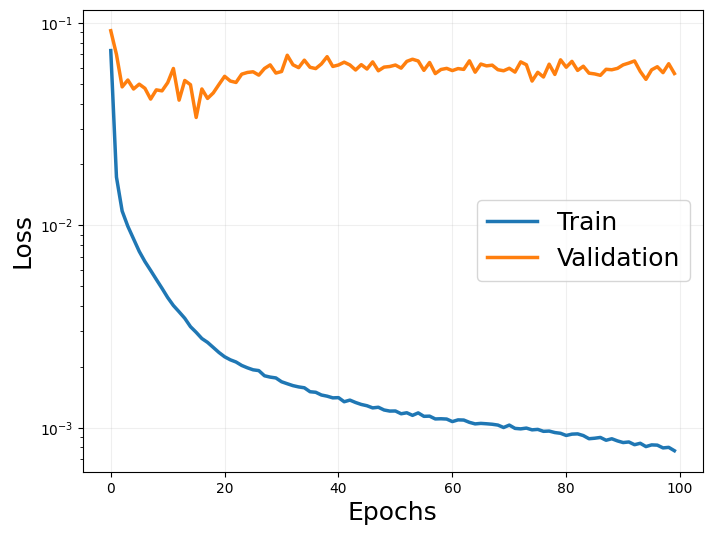

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(train_loss, label="Train", linewidth=2.5)
plt.plot(val_loss, label="Validation", linewidth=2.5)
plt.grid("on", alpha=0.2)
plt.legend(fontsize=18)
plt.yscale("log")
plt.xlabel("Epochs", fontsize=18)
plt.ylabel("Loss", fontsize=18)
plt.show()

# Evaluating results

In [ ]:
def rmse(true, pred):
    return (((true - pred) ** 2).mean() ** 0.5).detach().cpu().numpy()

def l2_error(true, pred):
    return np.linalg.norm(pred.detach().cpu().numpy() - true.detach().cpu().numpy()) / np.linalg.norm(true.detach().cpu().numpy())

def compute_metrics(model, loader, output_columns):
    model.eval()
    y_ = []
    pred_ = []
    preds = []
    ys = []
    for x, y in iter(loader):
        x, y = x.to(device).float(), y.to(device).float()
        pred = model(x)
        
        preds.append(pred)
        ys.append(y)

    ys = torch.cat(ys, dim=0) 
    preds = torch.cat(preds, dim=0)
    
    # Compute RMSE and L2 error for each feature
    rmse_values = []
    l2_error_values = []
    
    for i in range(ys.shape[1]):  # Iterate over each feature
        rmse_temp = rmse(ys[:, i], preds[:, i])
        l2_error_temp = l2_error(ys[:, i], preds[:, i])
        rmse_values.append(rmse_temp)
        l2_error_values.append(l2_error_temp)
        
        print(f"- Feature {output_columns[i]}:  RMSE: {rmse_temp:.5f}, L2 Error: {l2_error_temp:.5f}")
    
    # Compute overall RMSE across all features and samples
    overall_rmse = rmse(ys.flatten(), preds.flatten())
    print(f"Overall RMSE: {overall_rmse:.5f}")
    
    return rmse_values, l2_error_values, overall_rmse, ys, preds


In [ ]:
print("Validation Errors: ")
rmse_val, l2_error_val, overall_rmse_val, val_gt, val_pred = compute_metrics(model, val_loader, output_columns)

Validation Errors: 
- Feature do_diff04:  RMSE: 0.00870, L2 Error: 0.00862
- Feature scaled_chla_final06:  RMSE: 0.41079, L2 Error: 0.34046
- Feature doc_diff04:  RMSE: 0.00711, L2 Error: 0.00734
Overall RMSE: 0.23726


In [ ]:
print("Train Errors: ")
rmse_train, l2_error_train, overall_rmse_val, train_gt, train_pred = compute_metrics(model, train_loader, output_columns)

Train Errors: 
- Feature do_diff04:  RMSE: 0.00982, L2 Error: 0.00982
- Feature scaled_chla_final06:  RMSE: 0.04833, L2 Error: 0.05034
- Feature doc_diff04:  RMSE: 0.00600, L2 Error: 0.00600
Overall RMSE: 0.02868


In [ ]:
print("Test Errors: ")
rmse_test, l2_error_test, overall_rmse_val, test_gt, test_pred = compute_metrics(model, test_loader, output_columns)

Test Errors: 
- Feature do_diff04:  RMSE: 0.00907, L2 Error: 0.00906
- Feature scaled_chla_final06:  RMSE: 0.14788, L2 Error: 0.16750
- Feature doc_diff04:  RMSE: 0.00635, L2 Error: 0.00656
Overall RMSE: 0.08562


# Visualizing result

In [ ]:
def prepare_heatmap_data(data, df_main):
    # Create a DataFrame for visualization with depth and time as multi-index
    df = pd.DataFrame(data, columns=['predicted_value'])
    df['depth'] = df_main.reset_index(drop=True)['depth']
    df['datetime'] = df_main.reset_index(drop=True)['datetime'] 
    # Pivot to create a depth vs. time structure suitable for heatmap
    heatmap_data = df.pivot_table(index='depth', columns='datetime', values='predicted_value', aggfunc='mean')
    return heatmap_data

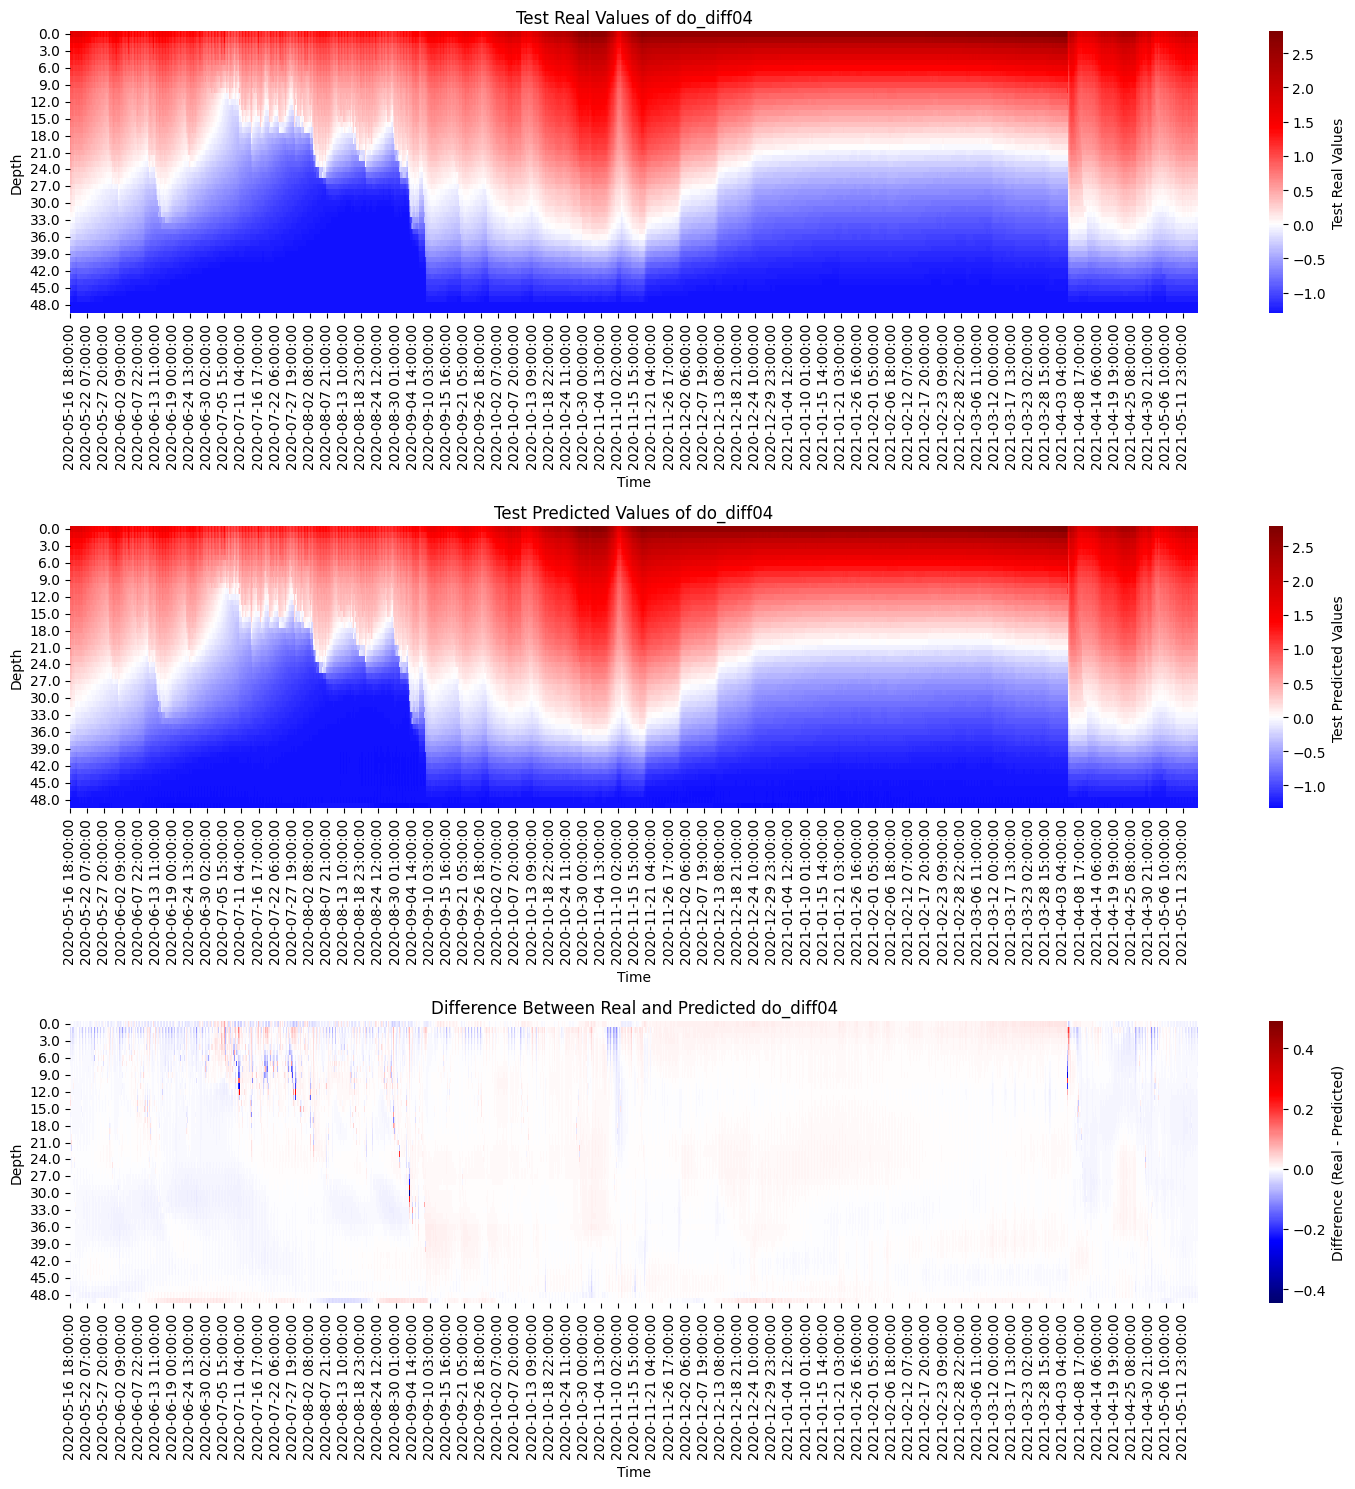

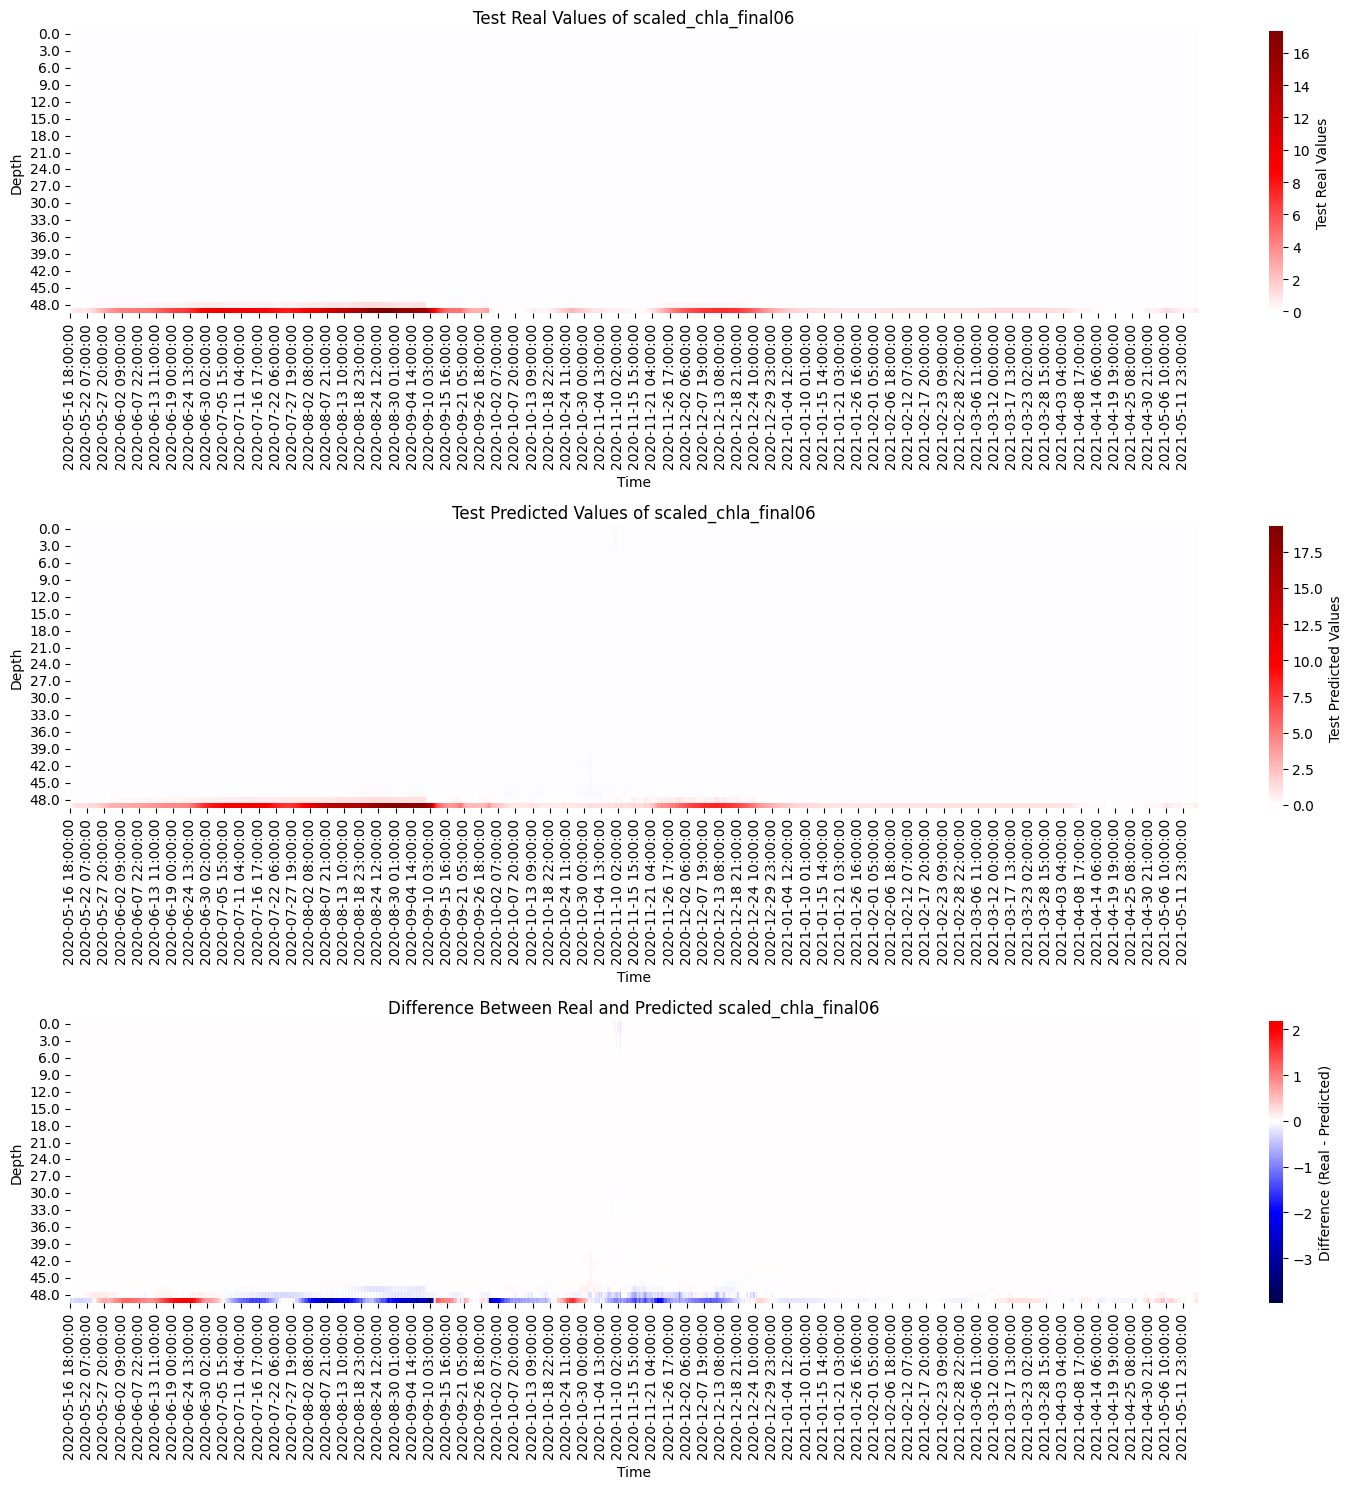

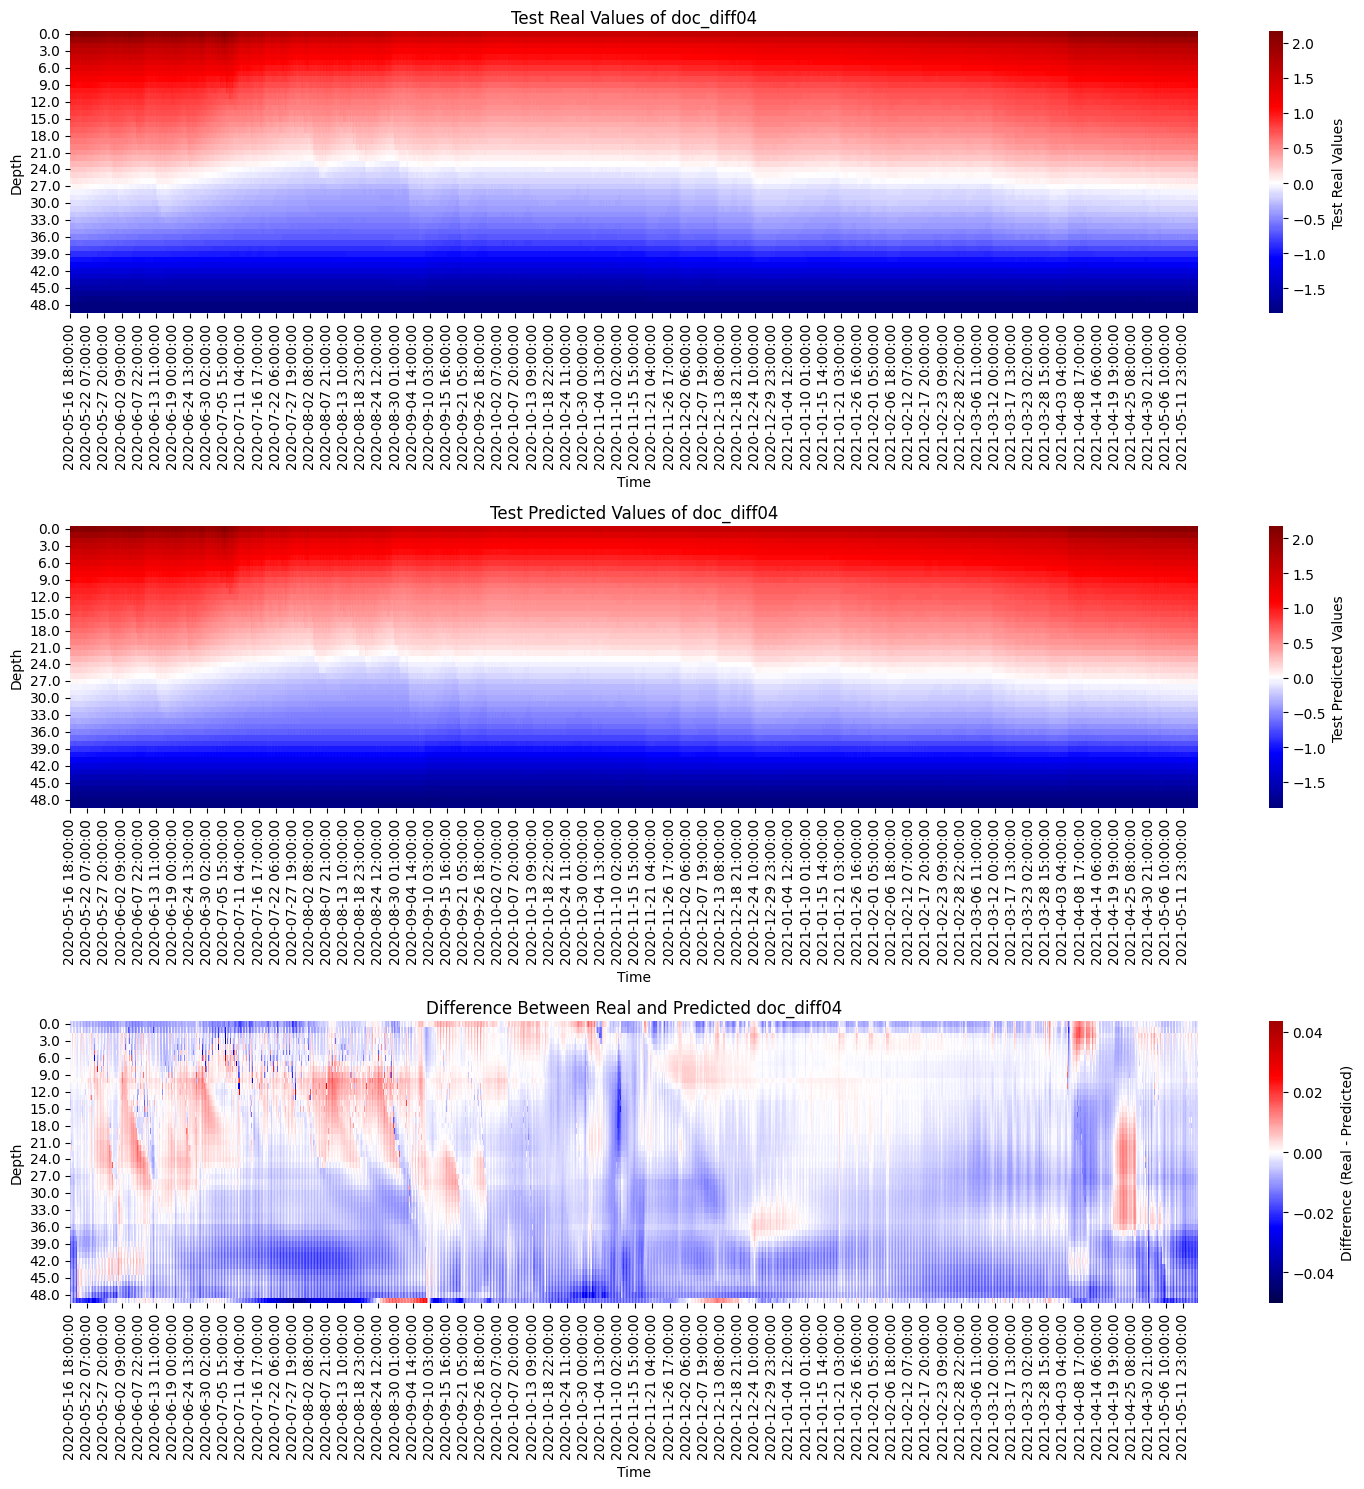

In [ ]:
for i in range(test_gt.shape[1]):
    # Prepare the data to plot heatmaps
    test_real_data = prepare_heatmap_data(test_gt.detach().cpu().numpy()[:,i], test_df_unnormalized)
    test_pred_data = prepare_heatmap_data(test_pred.detach().cpu().numpy()[:,i], test_df_unnormalized)
    difference_data = test_real_data - test_pred_data

    # Data for plotting
    heatmap_data = [
        (test_real_data, f'Test Real Values of {output_columns[i]}', 'seismic', 'Test Real Values'),
        (test_pred_data, f'Test Predicted Values of {output_columns[i]}', 'seismic', 'Test Predicted Values'),
        (difference_data, f'Difference Between Real and Predicted {output_columns[i]}', 'seismic', 'Difference (Real - Predicted)')
    ]

    # Plot heatmaps
    fig, axs = plt.subplots(len(heatmap_data), 1, figsize=(15, 15))

    for ax, (data, title, cmap, cbar_label) in zip(axs, heatmap_data):
        sns.heatmap(data, cmap=cmap, ax=ax, cbar_kws={'label': cbar_label}, center=0)
        ax.set_title(title)
        ax.set_xlabel('Time')
        ax.set_ylabel('Depth')

    plt.tight_layout()
    plt.show()
    

# Saving Model

In [ ]:
PATH = f"../saved_models/pretrain/m4.pth"
torch.save(model.state_dict(), PATH)